Random sample mean = 101.48613846633367
Random sample standard deviation = 19.524868221195696
Blood pressure sample mean = 80.55685365869508
Blood pressure sample standard deviation = 18.496676332084284


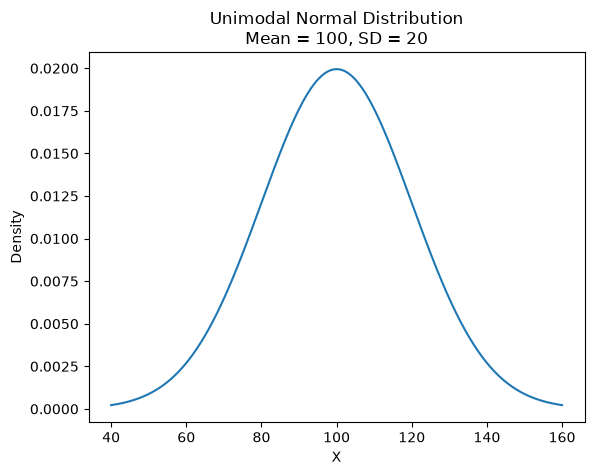

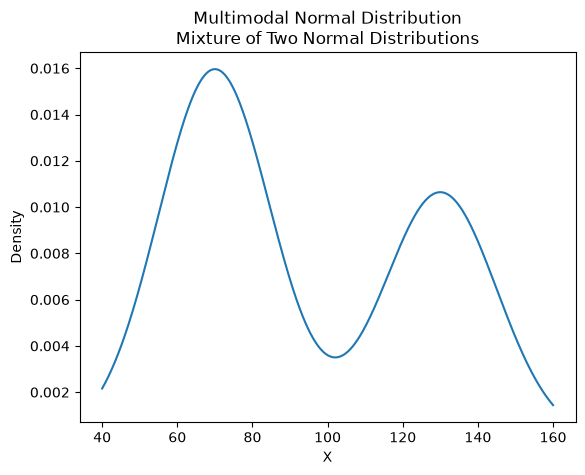

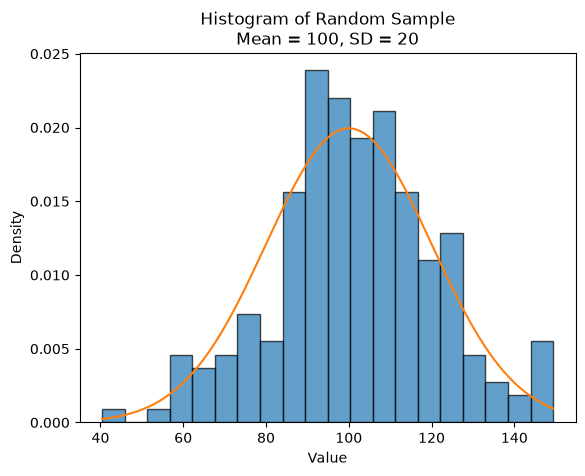

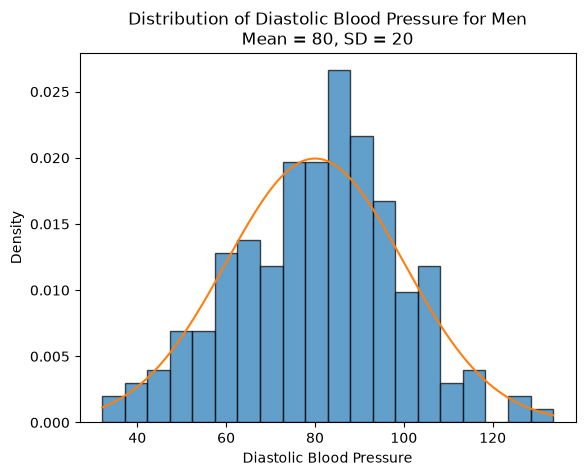

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


np.random.seed(10)

# ----------------------------------------------------
# Part 1: Unimodal Normal Distribution
# ----------------------------------------------------


x = np.linspace(40, 160, 1000)

# Unimodal normal distribution parameters
mean1 = 100
sd1 = 20

# Normal probability density function
y1 = norm.pdf(x, mean1, sd1)

# ----------------------------------------------------
# Part 2: Multimodal Normal Distribution
# ----------------------------------------------------

mean2_1 = 70
sd2_1 = 15

mean2_2 = 130
sd2_2 = 15

weight1 = 0.6
weight2 = 0.4

y2 = weight1 * norm.pdf(x, mean2_1, sd2_1) + weight2 * norm.pdf(x, mean2_2, sd2_2)

# ----------------------------------------------------
# Part 3: Random Sample Generation
# ----------------------------------------------------

sample = np.random.normal(100, 20, 200)

# ----------------------------------------------------
# Part 4: Diastolic Blood Pressure Sample
# ----------------------------------------------------

# Men's diastolic blood pressure normally distributed
# Mean = 80, SD = 20, Sample size = 200
bp_sample = np.random.normal(80, 20, 200)

# Sample result print
print("Random sample mean =", np.mean(sample))
print("Random sample standard deviation =", np.std(sample))

print("Blood pressure sample mean =", np.mean(bp_sample))
print("Blood pressure sample standard deviation =", np.std(bp_sample))

# ----------------------------------------------------
# Graph 1: Unimodal Normal Distribution
# ----------------------------------------------------

plt.plot(x, y1)
plt.xlabel("X")
plt.ylabel("Density")
plt.title("Unimodal Normal Distribution\nMean = 100, SD = 20")
plt.show()

# ----------------------------------------------------
# Graph 2: Multimodal Normal Distribution
# ----------------------------------------------------

plt.plot(x, y2)
plt.xlabel("X")
plt.ylabel("Density")
plt.title("Multimodal Normal Distribution\nMixture of Two Normal Distributions")
plt.show()

# ----------------------------------------------------
# Graph 3: Histogram of Random Sample
# ----------------------------------------------------

plt.hist(sample, bins=20, density=True, edgecolor="black", alpha=0.7)

# Normal curve overlay
x_sample = np.linspace(min(sample), max(sample), 1000)
y_sample = norm.pdf(x_sample, 100, 20)

plt.plot(x_sample, y_sample)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Histogram of Random Sample\nMean = 100, SD = 20")
plt.show()

# ----------------------------------------------------
# Graph 4: Histogram of Diastolic Blood Pressure
# ----------------------------------------------------

plt.hist(bp_sample, bins=20, density=True, edgecolor="black", alpha=0.7)

# Blood pressure normal curve overlay
x_bp = np.linspace(min(bp_sample), max(bp_sample), 1000)
y_bp = norm.pdf(x_bp, 80, 20)

plt.plot(x_bp, y_bp)
plt.xlabel("Diastolic Blood Pressure")
plt.ylabel("Density")
plt.title("Distribution of Diastolic Blood Pressure for Men\nMean = 80, SD = 20")
plt.show()

Mean triage time from data = 5.04
Mean treatment time from data = 20.2
Mean discharge time from data = 8.040000000000001

Simulation Results
Average triage time = 5.991709481243805
Average treatment time = 19.892873239461487
Average discharge time = 7.669088123793744
Average total patient time = 33.55367084449904
Bottleneck stage = Treatment


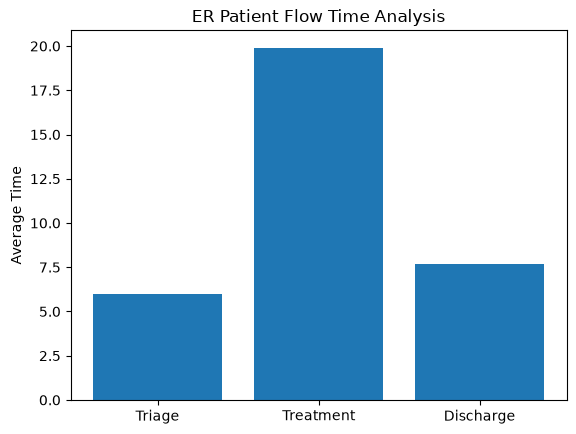

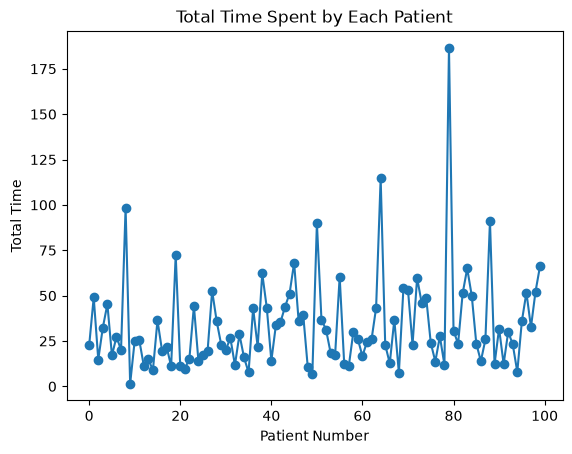

In [1]:
import random
import matplotlib.pyplot as plt

# Same random result পাওয়ার জন্য seed
random.seed(10)

# --------------------------------------------------
# Step 1: Sample observed data
# --------------------------------------------------

# Triage time sample data
triage_sample_data = [4.5, 5.0, 5.5, 4.8, 5.2, 4.7, 5.3, 5.1, 4.9, 5.4]

# Treatment time sample data
treatment_sample_data = [18, 20, 22, 19, 21, 23, 17, 20, 24, 18]

# Discharge time sample data
discharge_sample_data = [7.5, 8.0, 8.5, 7.8, 8.2, 7.7, 8.3, 8.1, 7.9, 8.4]

# --------------------------------------------------
# Step 2: Mean calculate from sample data
# --------------------------------------------------

mean_triage_time = sum(triage_sample_data) / len(triage_sample_data)
mean_treatment_time = sum(treatment_sample_data) / len(treatment_sample_data)
mean_discharge_time = sum(discharge_sample_data) / len(discharge_sample_data)

print("Mean triage time from data =", mean_triage_time)
print("Mean treatment time from data =", mean_treatment_time)
print("Mean discharge time from data =", mean_discharge_time)

# --------------------------------------------------
# Step 3: ER patient flow simulation
# --------------------------------------------------

patients = 100

triage_times = []
treatment_times = []
discharge_times = []
total_times = []

for patient in range(patients):

    # Sample data থেকে পাওয়া mean ব্যবহার করে time generate
    triage = random.expovariate(1 / mean_triage_time)
    treatment = random.expovariate(1 / mean_treatment_time)
    discharge = random.expovariate(1 / mean_discharge_time)

    # Total time for one patient
    total = triage + treatment + discharge

    # Data save
    triage_times.append(triage)
    treatment_times.append(treatment)
    discharge_times.append(discharge)
    total_times.append(total)

# --------------------------------------------------
# Step 4: Simulation result calculation
# --------------------------------------------------

avg_triage = sum(triage_times) / patients
avg_treatment = sum(treatment_times) / patients
avg_discharge = sum(discharge_times) / patients
avg_total_patient_time = sum(total_times) / patients

print("\nSimulation Results")
print("Average triage time =", avg_triage)
print("Average treatment time =", avg_treatment)
print("Average discharge time =", avg_discharge)
print("Average total patient time =", avg_total_patient_time)

# --------------------------------------------------
# Step 5: Bottleneck identification
# --------------------------------------------------

stage_names = ["Triage", "Treatment", "Discharge"]
average_times = [avg_triage, avg_treatment, avg_discharge]

max_time = max(average_times)
bottleneck_stage = stage_names[average_times.index(max_time)]

print("Bottleneck stage =", bottleneck_stage)

# --------------------------------------------------
# Graph 1: Average time by ER stage
# --------------------------------------------------

plt.bar(stage_names, average_times)
plt.ylabel("Average Time")
plt.title("ER Patient Flow Time Analysis")
plt.show()

# --------------------------------------------------
# Graph 2: Total time for each patient
# --------------------------------------------------

plt.plot(total_times, marker="o")
plt.xlabel("Patient Number")
plt.ylabel("Total Time")
plt.title("Total Time Spent by Each Patient")
plt.show()